# Retail Demand Forecasting

**Business Problem**

Companies and retailers need to:
✅ predict product demand accurately

Why?
Because they must:
- optimize inventory levels
- avoid stock shortages and overstocking
- improve supply chain management
- forecast future product demand
- increase sales and operational efficiency
- reduce storage and inventory costs

| Column Name      | Meaning                   | Type            | Example      | Importance                       |
| ---------------- | ------------------------- | --------------- | ------------ | -------------------------------- |
| Product_id       | Unique product identifier | Numerical       | 786725       | Identifies each product          |
| Product_Code     | Product code              | Categorical     | Product_0033 | Helps distinguish products       |
| Warehouse        | Warehouse location        | Categorical     | Whse_S       | Indicates storage location       |
| Product_Category | Category of product       | Categorical     | Category_005 | Helps analyze category demand    |
| Date             | Date of order             | Datetime        | 01/03/2016   | Used to extract time features    |
| Order_Demand     | Demand quantity           | Target Variable | 16000        | Value to be predicted            |
| Open             | Store open status         | Numerical       | 1            | Indicates whether store is open  |
| Promo            | Promotion status          | Numerical       | 0            | Promotions affect demand         |
| StateHoliday     | State holiday indicator   | Numerical       | 0            | Holidays influence sales         |
| SchoolHoliday    | School holiday indicator  | Numerical       | 0            | Can impact demand patterns       |
| Petrol_price     | Fuel price                | Numerical       | 59.8         | Economic factor affecting demand |


# PHASE 1 : RETAIL DATA UNDERSTANDING AND ANALYSIS

### Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 — Load Dataset

In [3]:
df = pd.read_csv("Retail_Dataset2.csv")

### Step 3 — View First Rows

In [4]:
df.head()

,Product_id,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
0,786725,Product_0033,Whse_S,Category_005,01/03/2016,16000,1,0,0,0,91
1,786743,Product_1825,Whse_S,Category_006,01/03/2016,50000,1,0,0,0,85
2,786967,Product_0551,Whse_S,Category_030,01/03/2016,3000,1,0,0,0,85
3,786856,Product_0556,Whse_S,Category_030,01/03/2016,1000,1,0,0,0,93
4,899538,Product_1844,Whse_A,Category_018,01/03/2016,7,1,0,0,0,95


### Step 4 — Dataset Shape

In [5]:
df.shape

(169211, 11)

### Step 5 — Column Names

In [6]:
df.columns

Index(['Product_id', 'Product_Code', 'Warehouse', 'Product_Category', 'Date',
       'Order_Demand', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'Petrol_price'],
      dtype='str')

### Step 6 — Dataset Info

In [7]:
pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non Null Count": df.notnull().sum().values,
    "Null Count": df.isnull().sum().values
})

,Column Name,Data Type,Non Null Count,Null Count
0,Product_id,int64,169211,0
1,Product_Code,str,169211,0
2,Warehouse,str,169211,0
3,Product_Category,str,169211,0
4,Date,str,169211,0
5,Order_Demand,int64,169211,0
6,Open,int64,169211,0
7,Promo,int64,169211,0
8,StateHoliday,str,169211,0
9,SchoolHoliday,int64,169211,0


### Step 7 — Statistical Summary

In [8]:
df.describe()

,Product_id,Order_Demand,Open,Promo,SchoolHoliday,Petrol_price
count,1.692110e+05,1.692110e+05,169211.000000,169211.000000,169211.000000,169211.000000
mean,9.528887e+05,5.248118e+03,0.817742,0.395364,0.133401,87.986183
std,5.555751e+04,3.116296e+04,0.386058,0.488930,0.340009,4.909978
min,6.909430e+05,0.000000e+00,0.000000,0.000000,0.000000,80.000000
25%,9.054275e+05,2.000000e+01,1.000000,0.000000,0.000000,84.000000
50%,9.526430e+05,3.000000e+02,1.000000,0.000000,0.000000,88.000000
75%,1.001416e+06,2.000000e+03,1.000000,1.000000,0.000000,92.000000
max,1.048574e+06,2.500000e+06,1.000000,1.000000,1.000000,96.000000


### Step 8 — Missing Values

In [9]:
df.isnull().sum()

Product_id          0
Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Petrol_price        0
dtype: int64

### Step 9 — Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

### Step 10 — Convert Date Column

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

### Step 11 — Verify Conversion

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 169211 entries, 0 to 169210
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Product_id        169211 non-null  int64         
 1   Product_Code      169211 non-null  str           
 2   Warehouse         169211 non-null  str           
 3   Product_Category  169211 non-null  str           
 4   Date              169211 non-null  datetime64[us]
 5   Order_Demand      169211 non-null  int64         
 6   Open              169211 non-null  int64         
 7   Promo             169211 non-null  int64         
 8   StateHoliday      169211 non-null  str           
 9   SchoolHoliday     169211 non-null  int64         
 10  Petrol_price      169211 non-null  int64         
dtypes: datetime64[us](1), int64(6), str(4)
memory usage: 14.2 MB


### Step 12 — Order Demand Distribution

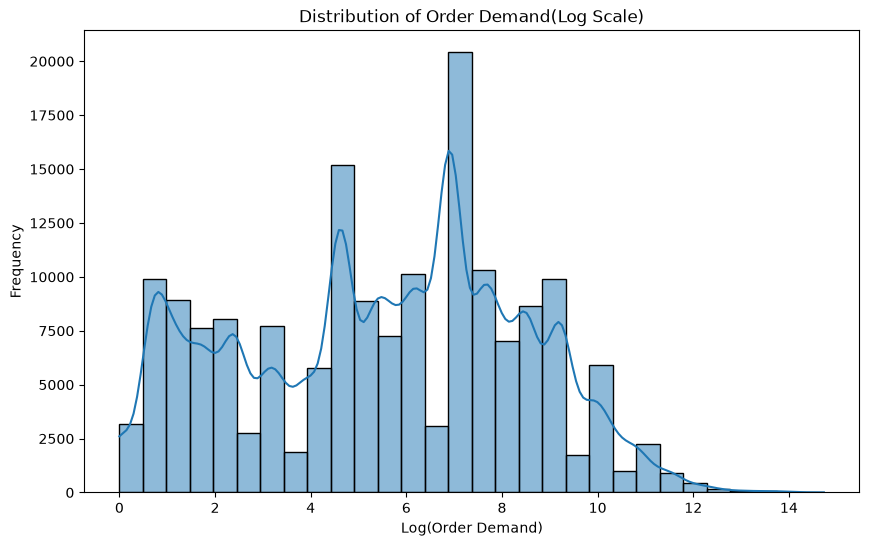

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(np.log1p(df['Order_Demand']), bins=30, kde=True)

plt.title('Distribution of Order Demand(Log Scale)')
plt.xlabel('Log(Order Demand)')
plt.ylabel('Frequency')

plt.show()

### Step 13 — Warehouse Distribution

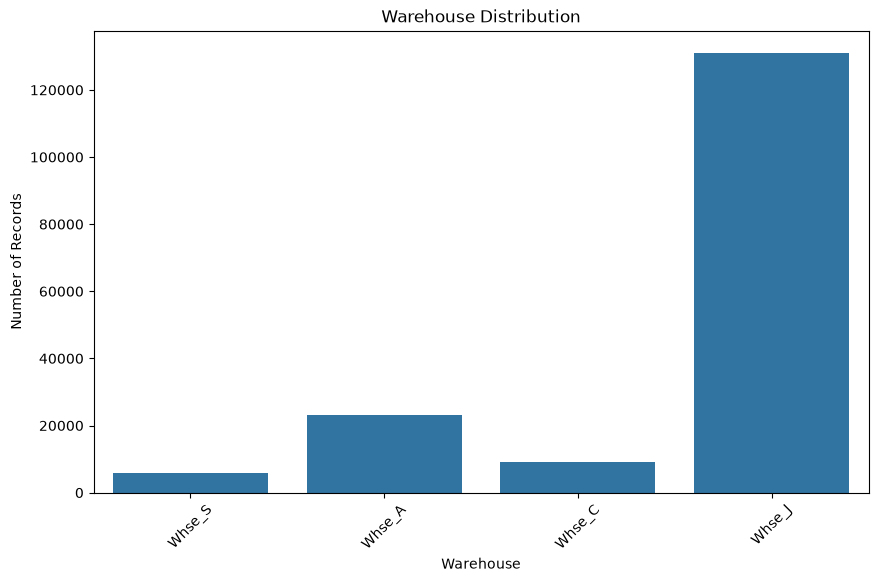

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(x='Warehouse', data=df)

plt.title('Warehouse Distribution')
plt.xlabel('Warehouse')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)

plt.show()

### Step 14 — Product Category Distribution

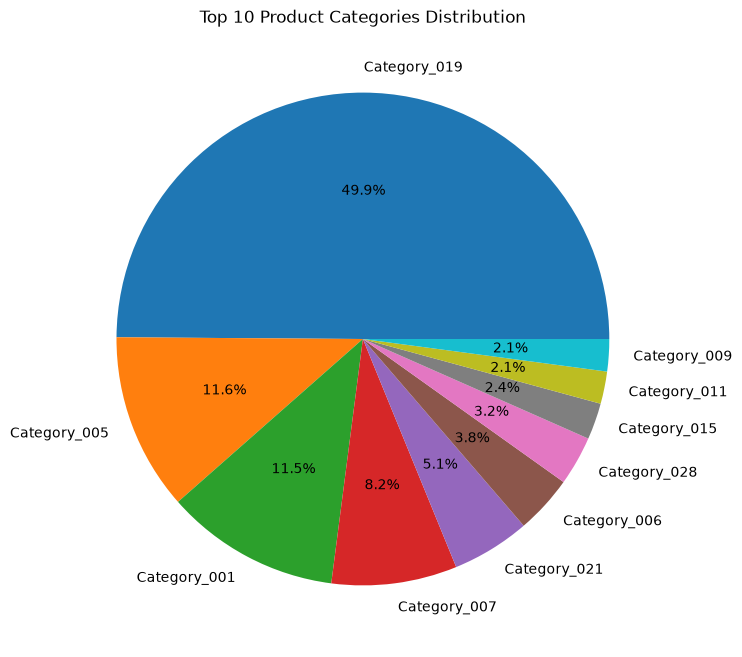

In [15]:
plt.figure(figsize=(8,8))

top_categories = df['Product_Category'].value_counts().head(10)

plt.pie(top_categories,
        labels=top_categories.index,
        autopct='%1.1f%%')

plt.title('Top 10 Product Categories Distribution')

plt.show()

### Step 17 — Petrol Price vs Order Demand

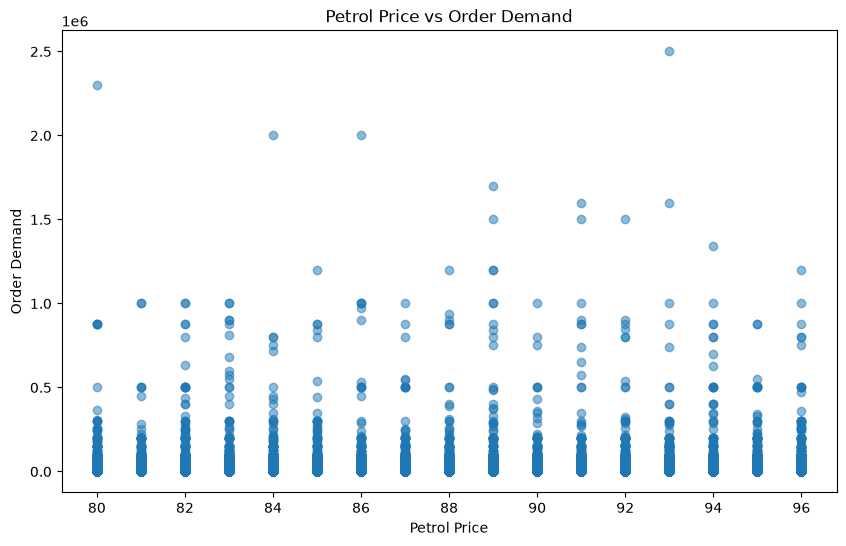

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(df['Petrol_price'],
            df['Order_Demand'],
            alpha=0.5)

plt.title('Petrol Price vs Order Demand')
plt.xlabel('Petrol Price')
plt.ylabel('Order Demand')

plt.show()

### Step 16 — Correlation Heatmap

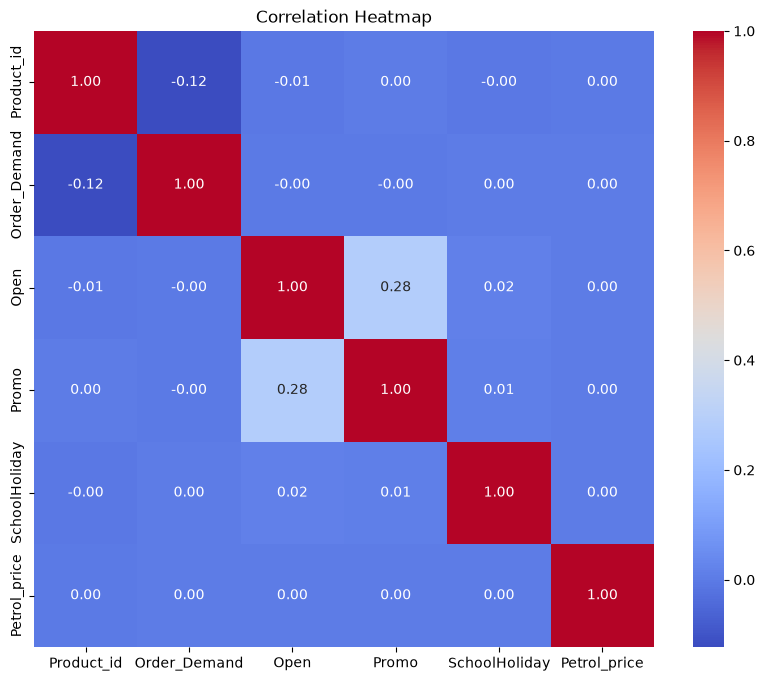

In [17]:
plt.figure(figsize=(10,8))

numerical_columns = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numerical_columns.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

### Step 17 — Order Demand Box Plot

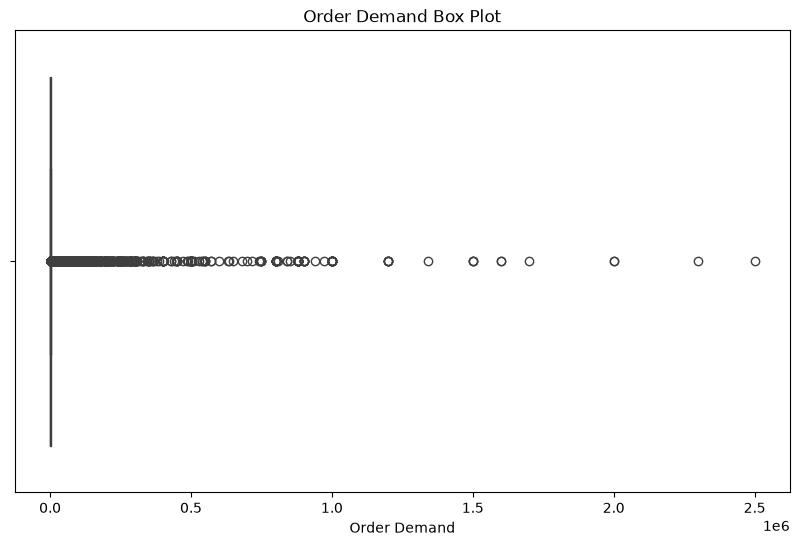

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['Order_Demand'])

plt.title('Order Demand Box Plot')
plt.xlabel('Order Demand')

plt.show()

## PHASE 2 — Retail Feature Engineering

### Step 1 — Extract Time Intelligence Features

#### Year Feature

In [19]:
df["Year"] = df["Date"].dt.year

#### Month Feature

In [20]:
df["Month"] = df["Date"].dt.month

#### Day Feature

In [21]:
df["Day"] = df["Date"].dt.day

#### Weekday Feature

In [22]:
df["Weekday"] = df["Date"].dt.weekday

#### Quarter Feature

In [23]:
df["Quarter"] = df["Date"].dt.quarter

In [24]:
df[["Date", "Year", "Month", "Day", "Weekday", "Quarter"]].head()

,Date,Year,Month,Day,Weekday,Quarter
0,2016-01-03,2016,1,3,6,1
1,2016-01-03,2016,1,3,6,1
2,2016-01-03,2016,1,3,6,1
3,2016-01-03,2016,1,3,6,1
4,2016-01-03,2016,1,3,6,1


### Step 2 — Weekend Indicator

#### Create Weekend Feature

In [25]:
df["Weekend"] = df["Weekday"].apply(
    lambda x: 1 if x >= 5 else 0
)

Captures:

✅ weekend demand patterns

Very important in:

- retail analytics
- inventory planning

In [26]:
df[["Weekday", "Weekend"]].head(10)

,Weekday,Weekend
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1
5,6,1
6,6,1
7,6,1
8,6,1
9,6,1


### Step 3 — Promotion Impact Feature

#### Create Promotion Impact Feature

In [27]:
df["Promotion_Impact"] = (
    df["Promo"] * df["Open"]
)

Captures:

✅ promotional sales periods

Very important in:

- demand forecasting
- retail analytics
- inventory optimization

In [28]:
df[["Promo", "Open", "Promotion_Impact"]].head()

,Promo,Open,Promotion_Impact
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


### Step 4 — Lag Feature

#### Previous Demand Feature

In [29]:
df["Previous_Demand"] = df[
    "Order_Demand"
].shift(1)

Captures:

✅ previous demand pattern

Very important in:

- retail demand forecasting
- sales prediction
- inventory optimization

In [30]:
df[
    ["Order_Demand", "Previous_Demand"]
].head(10)

,Order_Demand,Previous_Demand
0,16000,NaN
1,50000,16000.0
2,3000,50000.0
3,1000,3000.0
4,7,1000.0
5,2000,7.0
6,2,2000.0
7,300,2.0
8,3000,300.0
9,5000,3000.0


### Step 5 — Rolling Average Feature

#### 7-Day Rolling Mean

In [31]:
df["Rolling_Mean_7"] = df[
    "Order_Demand"
].shift(1).rolling(window=7).mean()

Captures:

✅ recent demand trends

✅ demand momentum

✅ smoothing fluctuations

Very important in:

- retail demand forecasting
- inventory planning
- sales trend analysis

In [32]:
df[
    ["Order_Demand",
     "Previous_Demand",
     "Rolling_Mean_7"]
].head(15)

,Order_Demand,Previous_Demand,Rolling_Mean_7
0,16000,NaN,NaN
1,50000,16000.0,NaN
2,3000,50000.0,NaN
3,1000,3000.0,NaN
4,7,1000.0,NaN
5,2000,7.0,NaN
6,2,2000.0,NaN
7,300,2.0,10287.000000
8,3000,300.0,8044.142857
9,5000,3000.0,1329.857143


### Step 6 — Handle Missing Values

Lag & Rolling Features create null values.

#### Check Null Values

In [33]:
df.isnull().sum()

Product_id          0
Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Petrol_price        0
Year                0
Month               0
Day                 0
Weekday             0
Quarter             0
Weekend             0
Promotion_Impact    0
Previous_Demand     1
Rolling_Mean_7      7
dtype: int64

#### Fill Missing Values

In [34]:
df = df.bfill()

#### Verify Missing Values

In [35]:
df.isnull().sum()

Product_id          0
Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Petrol_price        0
Year                0
Month               0
Day                 0
Weekday             0
Quarter             0
Weekend             0
Promotion_Impact    0
Previous_Demand     0
Rolling_Mean_7      0
dtype: int64

### Step 7 — Encode Categorical Features

In [36]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Product Code
df["Product_Code"] = label_encoder.fit_transform(
    df["Product_Code"].astype(str)
)

# Warehouse
df["Warehouse"] = label_encoder.fit_transform(
    df["Warehouse"].astype(str)
)

# Product Category
df["Product_Category"] = label_encoder.fit_transform(
    df["Product_Category"].astype(str)
)

# State Holiday
df["StateHoliday"] = label_encoder.fit_transform(
    df["StateHoliday"].astype(str)
)

### Step 8 — Verify Encoded Features

In [37]:
df[["Product_Code", "Warehouse", "Product_Category", "StateHoliday"]].head()

,Product_Code,Warehouse,Product_Category,StateHoliday
0,32,3,2,0
1,1772,3,3,0
2,543,3,26,0
3,548,3,26,0
4,1791,0,15,0


### Step 9 — Drop Date Column

In [38]:
df.drop("Date", axis=1, inplace=True)

### Step 10 — Feature Engineering Correlation Heatmap

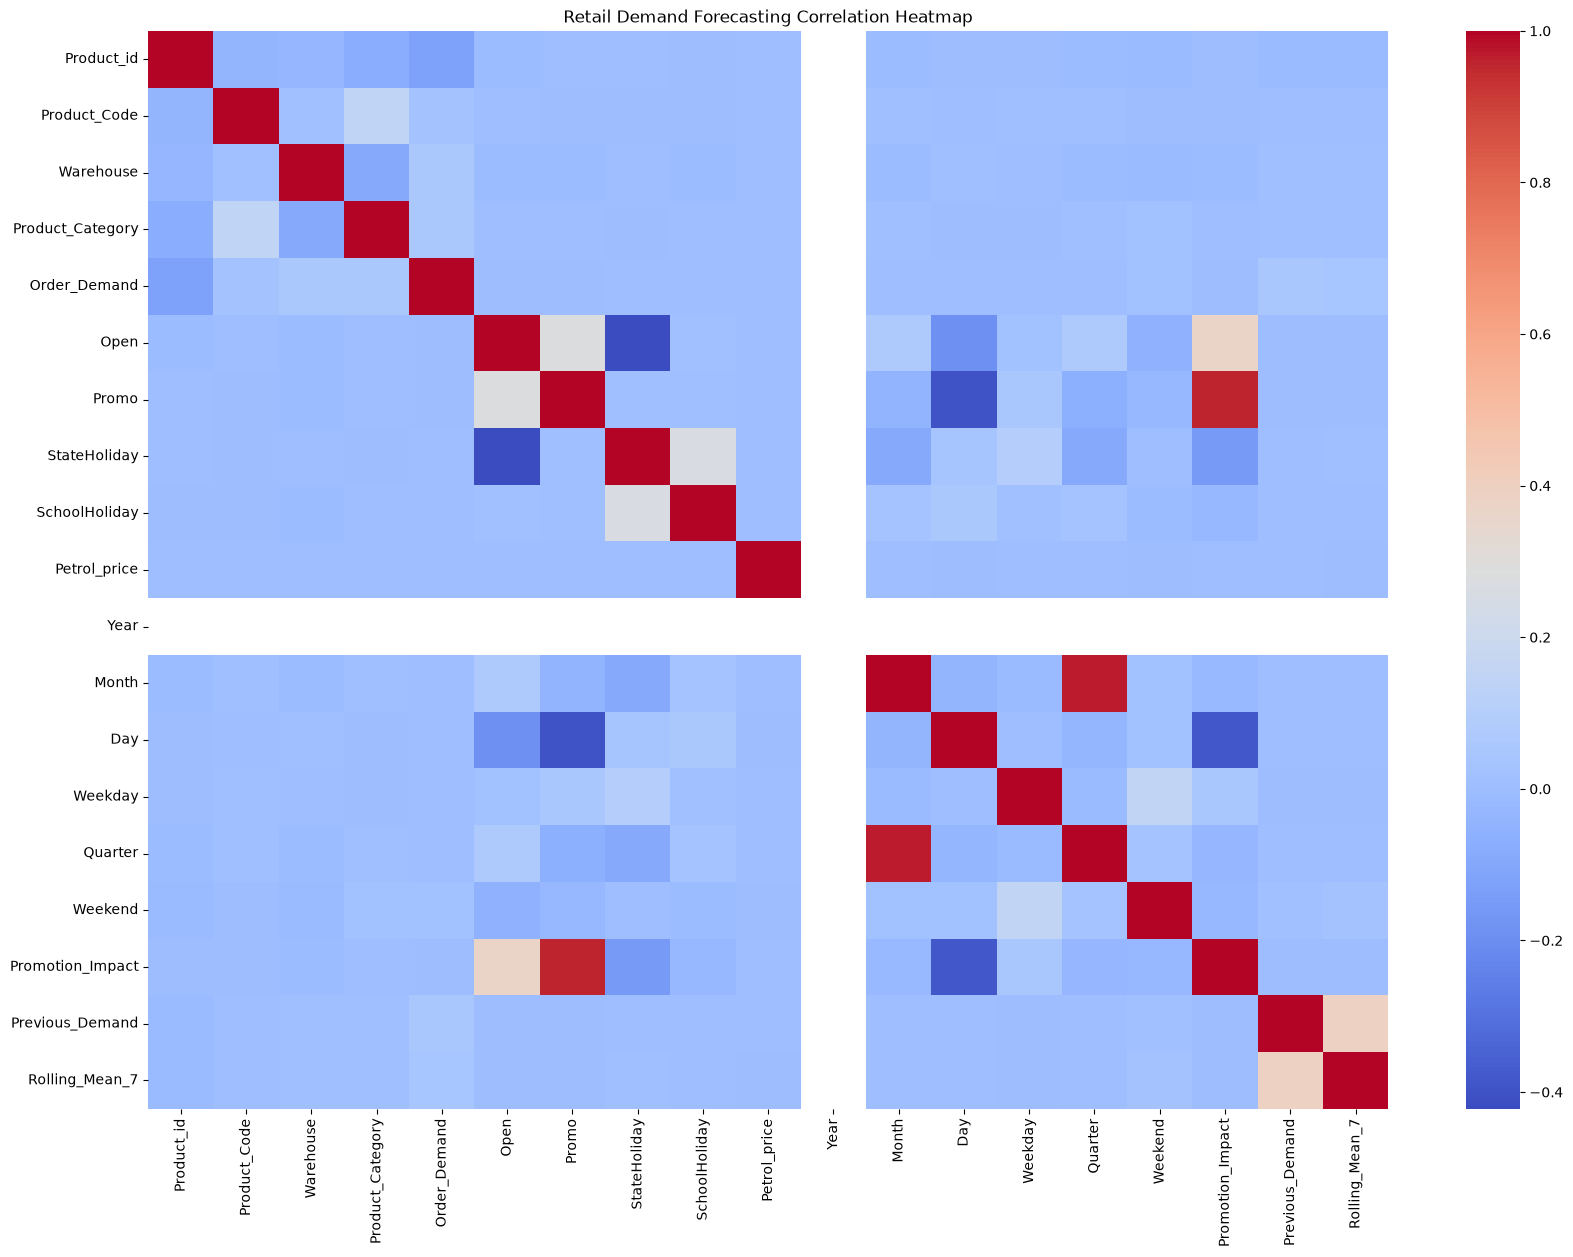

In [39]:
plt.figure(figsize=(20,14))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Retail Demand Forecasting Correlation Heatmap")

plt.show()

### Step 11 — Features & Target

#### Features

In [40]:
X = df.drop("Order_Demand", axis=1)

#### Target

In [41]:
y = df["Order_Demand"]

### Step 12 — Train-Test Split

For forecasting:

✅ use shuffle=False

Forecasting follows:

Past → Future

NOT random mixing.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

### Step 13 — Verify Dataset Shapes

In [43]:
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape : (135368, 18)
X_test shape : (33843, 18)
y_train shape : (135368,)
y_test shape : (33843,)


## PHASE 3 — Retail Demand Prediction Model

✅ Random Forest Regressor

Why?
- handles nonlinear sensor interactions
- robust with environmental data
- stable forecasting
- excellent feature importance analysis

### Step 1 — Import Algorithm

In [44]:
from sklearn.ensemble import RandomForestRegressor

### Step 2 — Create Model

In [45]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

| Parameter        | Meaning              |
| ---------------- | -------------------- |
| n_estimators=300 | Number of trees      |
| max_depth=20     | Controls complexity  |
| n_jobs=-1        | Uses all CPU cores   |
| random_state=42  | Reproducible results |


### Step 3 — Train Model

In [46]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

### Step 4 — Predict Test Data

In [47]:
y_pred = rf_model.predict(X_test)

### Step 5 — Import Evaluation Metrics

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Step 6 — Calculate Metrics

In [49]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

### Step 7 — Print Results

In [50]:
print("Retail Demand Forecasting Results")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

Retail Demand Forecasting Results
MAE : 4067.824551725131
RMSE : 23569.95607281818
R2 Score : 0.4472395382762778


Interpretation:

- MAE shows average prediction error.
- RMSE measures prediction accuracy.
- R² Score indicates how well the model explains demand variation.

Higher R² Score means better forecasting performance.

### Step 8 — Feature Importance

#### Create Importance DataFrame

In [51]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

             Feature  Importance
0         Product_id    0.389986
1       Product_Code    0.247457
17    Rolling_Mean_7    0.091475
16   Previous_Demand    0.063913
8       Petrol_price    0.048649
11               Day    0.041204
10             Month    0.032043
2          Warehouse    0.021179
12           Weekday    0.015580
3   Product_Category    0.012552
13           Quarter    0.010997
5              Promo    0.006562
7      SchoolHoliday    0.006282
15  Promotion_Impact    0.004890
4               Open    0.003691
6       StateHoliday    0.003284
14           Weekend    0.000254
9               Year    0.000000


### Step 9 — Visualize Feature Importance

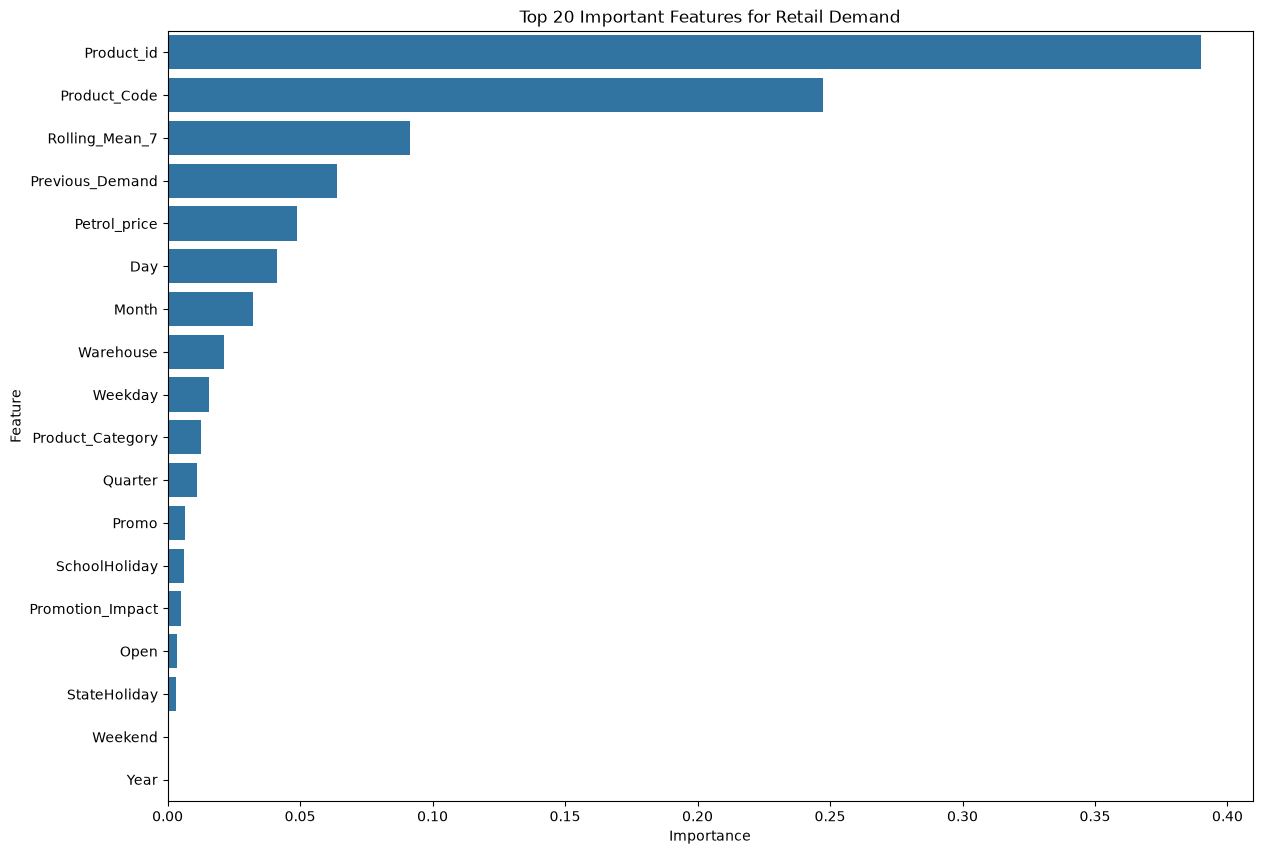

In [52]:
plt.figure(figsize=(14,10))

sns.barplot(
    x=importance["Importance"][:20],
    y=importance["Feature"][:20]
)

plt.title("Top 20 Important Features for Retail Demand")

plt.show()

### Step 10 — Actual vs Predicted Visualization

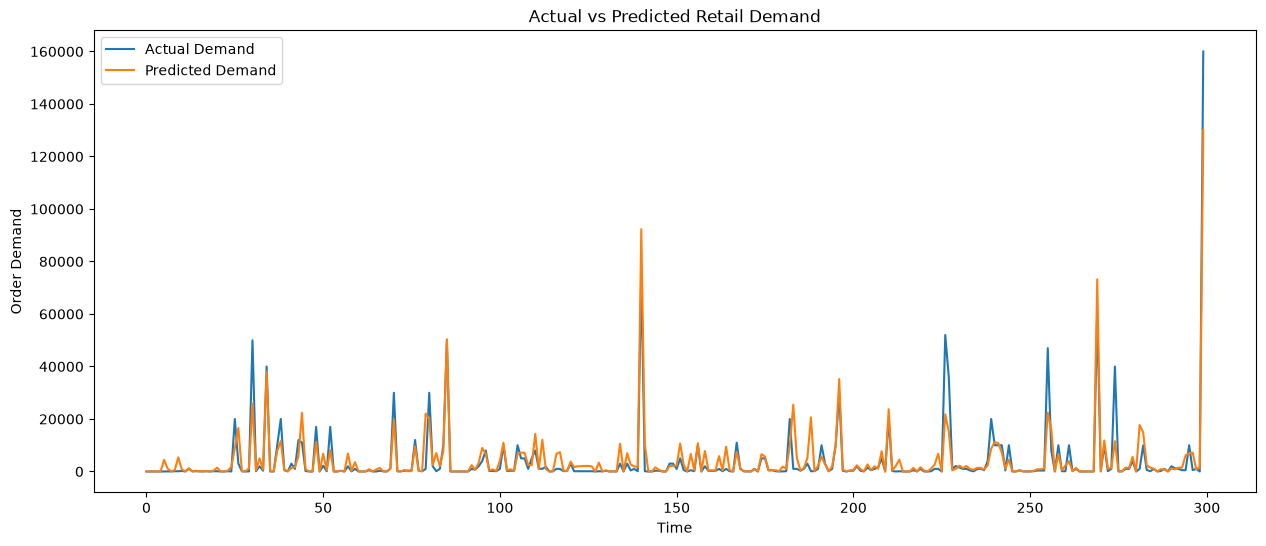

In [53]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:300],
    label="Actual Demand"
)

plt.plot(
    y_pred[:300],
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Retail Demand")

plt.xlabel("Time")

plt.ylabel("Order Demand")

plt.legend()

plt.show()

### Step 11 — Demand Trend Comparison

In [54]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": y_pred[:20]
})

print(comparison)

    Actual    Predicted
0        5     9.127064
1        5    37.636000
2       10    58.314935
3        6     2.800000
4        3     5.485706
5        0  4459.314108
6       50  1088.978000
7        1    69.433031
8      100   510.779786
9      100  5385.495642
10     200   830.584814
11      14    10.901087
12    1000  1278.776180
13      50    61.794677
14     100   297.907634
15      40    81.272336
16      22    79.841569
17     100   188.022536
18      10    12.019649
19     100   294.676209


## PHASE 4 — Smart Retail Demand Prediction System

### Step 1 — Create New Future Input Data

#### Create New Input

In [55]:
new_data = pd.DataFrame({
    "Product_id": [786725],
    "Product_Code": [10],
    "Warehouse": [1],
    "Product_Category": [4],
    "Open": [1],
    "Promo": [1],
    "StateHoliday": [0],
    "SchoolHoliday": [0],
    "Petrol_price": [59.8],

    "Year": [2016],
    "Month": [3],
    "Day": [15],
    "Weekday": [2],
    "Quarter": [1],
    "Weekend": [0],

    "Promotion_Impact": [1],
    "Previous_Demand": [12000],
    "Rolling_Mean_7": [11500]
})

### Step 2 — Match Training Columns

In [56]:
new_data = new_data[X.columns]

### Step 3 — Predict Retail Demand

In [57]:
future_prediction = rf_model.predict(new_data)

### Step 4 — Display Prediction

In [58]:
print("Predicted Retail Demand:")
print(future_prediction[0])

Predicted Retail Demand:
47862.05962962963


# Retail Demand Forecasting System

Including:

✅ data preprocessing and cleaning

✅ time-based feature engineering

✅ demand trend analysis

✅ weekend and promotion effect modeling

✅ lag and rolling mean forecasting features

✅ Random Forest regression model

✅ feature importance analysis

✅ actual vs predicted demand evaluation

✅ future retail demand prediction system

✅ reusable demand forecasting framework